<a href="https://colab.research.google.com/github/stephenchen0814/04-LinearReg_Salary/blob/main/Gradient%20Boost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error,log_loss
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.ensemble import GradientBoostingRegressor,GradientBoostingClassifier
from sklearn.metrics import confusion_matrix

from sklearn.inspection import permutation_importance
from sklearn.utils.fixes import parse_version

from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight

from matplotlib.pylab import rcParams
import xgboost as xgb

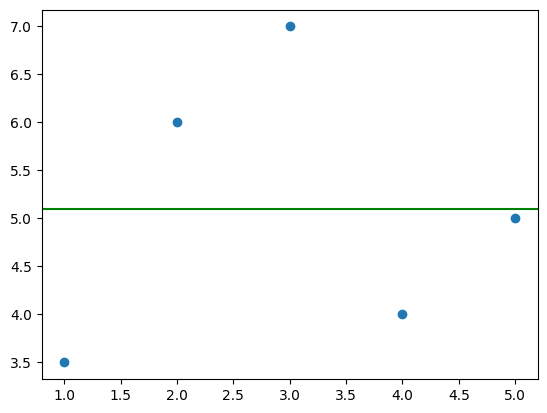

In [47]:
X=np.array([1,2,3,4,5]).reshape(-1,1)
y=np.array([3.5,6,7,4,5])
plt.scatter(X,y)
plt.axhline(y.mean(), color='green')

plt.show()

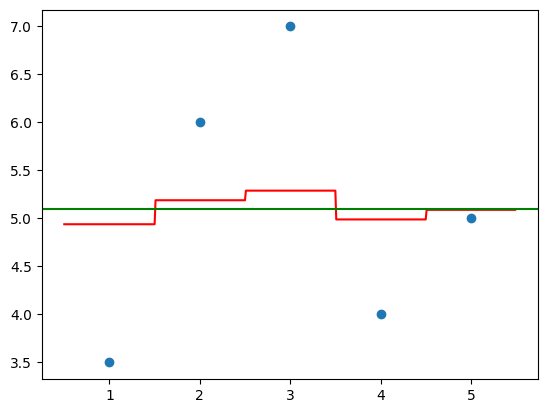

In [48]:
model1=GradientBoostingRegressor(n_estimators=1)
model1.fit(X,y)

xval=np.arange(0.5,5.5,0.01).reshape(-1,1)
pred=model1.predict(xval)
plt.scatter(X,y)
plt.plot(xval, pred, 'r')
plt.axhline(y.mean(), color='green')
plt.show()

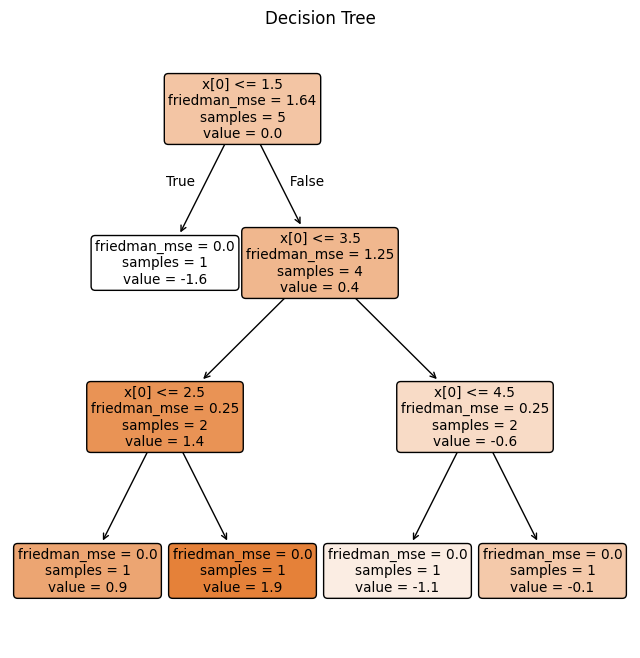

In [49]:
plt.figure(figsize=(8,8))
plot_tree(model1.estimators_[0][0], filled=True, rounded=True)
plt.title("Decision Tree")
plt.show()

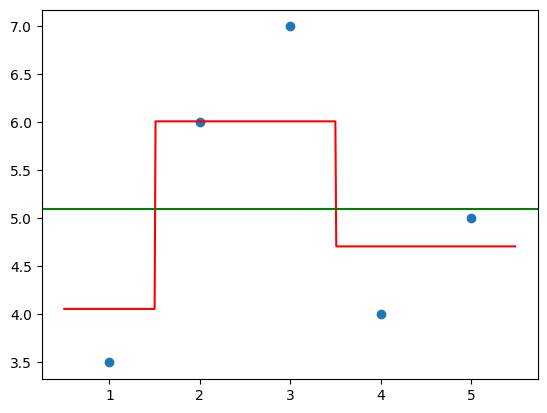

In [50]:
model2=GradientBoostingRegressor(max_depth =2, n_estimators=10)
model2.fit(X,y)

xval=np.arange(0.5,5.5,0.01).reshape(-1,1)
pred=model2.predict(xval)
plt.scatter(X,y)
plt.plot(xval, pred, 'r')
plt.axhline(y.mean(), color='green')
plt.show()

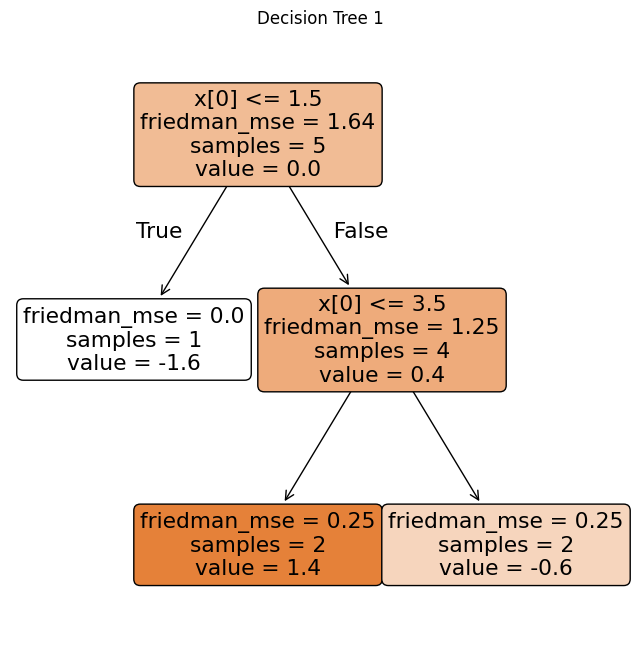

In [51]:
plt.figure(figsize=(8, 8))
plot_tree(model2.estimators_[0][0], filled=True, rounded=True)
plt.title("Decision Tree 1")
plt.show()

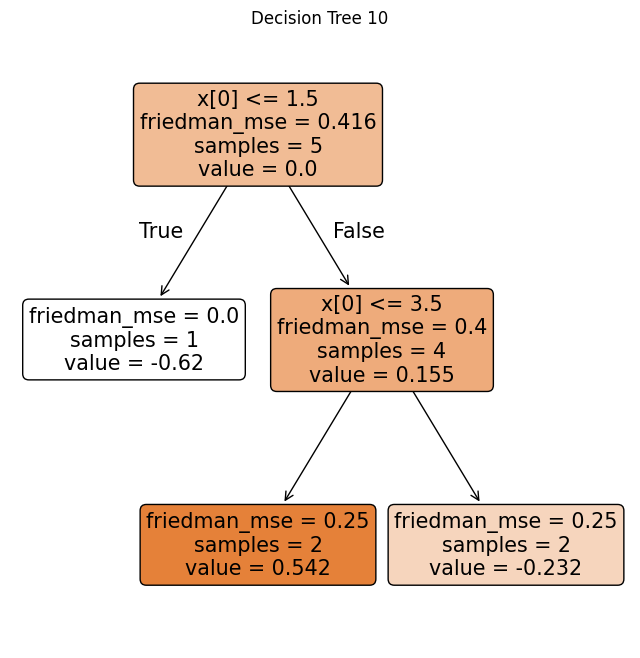

In [52]:
plt.figure(figsize=(8, 8))
plot_tree(model2.estimators_[9][0], filled=True, rounded=True)
plt.title("Decision Tree 10")
plt.show()

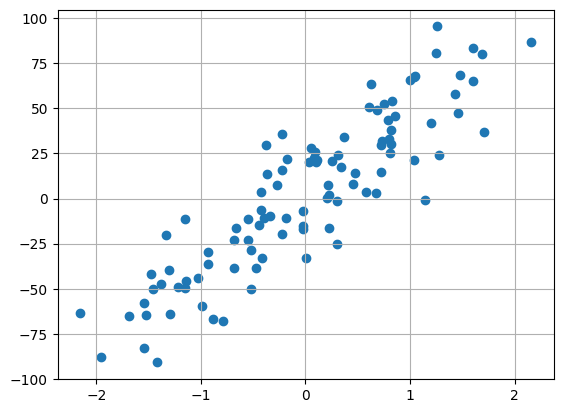

In [53]:
X, y = datasets.make_regression(n_samples=100, n_features=1, noise=20)
fig=plt.figure()
xv=np.linspace(0,5, 1000)
plt.grid()

plt.scatter(X,y)
plt.show()

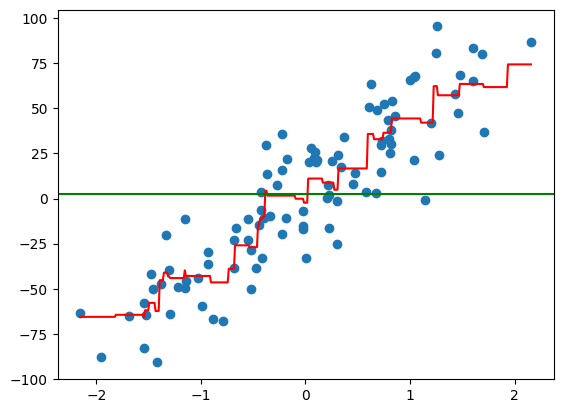

In [54]:
model3=GradientBoostingRegressor(max_depth=2, n_estimators=40)
model3.fit(X,y)

xval=np.arange(X.min(),X.max(),0.01).reshape(-1,1)
pred=model3.predict(xval)
plt.scatter(X,y)
plt.plot(xval, pred, 'r')
plt.axhline(y.mean(), color='green')
plt.show()

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [61]:
param_dist  = {
              'n_estimators': [30, 100, 200],
              'max_depth' : [2,3,4,5],
              'learning_rate' :[0.01, 0.1]
             }

In [57]:
model=GradientBoostingRegressor()
tree_cv = GridSearchCV(model, param_dist, cv=5)

tree_cv.fit(X_train, y_train)
print("Tuned Parameters: {}".format(tree_cv.best_params_))
print("Best score is {}".format(tree_cv.best_score_))

Tuned Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 30}
Best score is 0.7318506469981472


In [63]:
n_estimators=30

In [64]:
model4=GradientBoostingRegressor(max_depth=2, n_estimators=n_estimators, learning_rate=0.1)
model4.fit(X_train,y_train)

GradientBoostingRegressor(max_depth=2, n_estimators=30)

In [66]:
pred=model4.predict(X_test)
model4.train_score_
model4.score(X_test,y_test)

0.7199529618896066

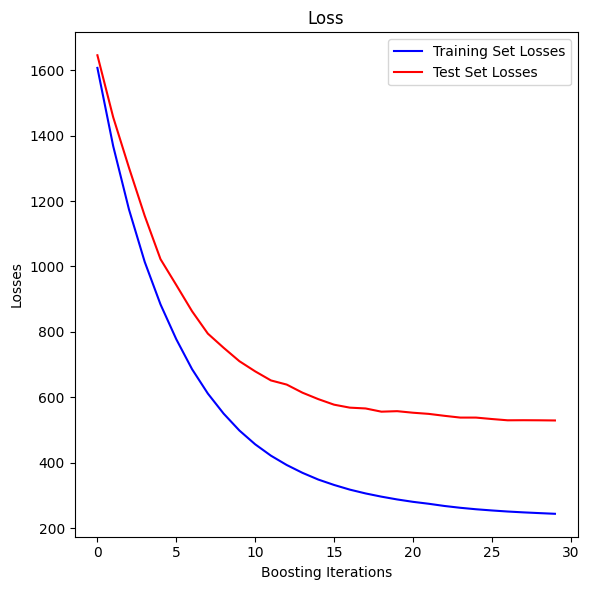

In [67]:
losses = np.zeros((n_estimators,), dtype=np.float64)
for i, y_pred in enumerate(model4.staged_predict(X_test)):
    losses[i] = mean_squared_error(y_test, y_pred)

fig = plt.figure(figsize=(6, 6))
plt.subplot(1, 1, 1)
plt.title("Loss")
plt.plot(
    np.arange(n_estimators),
    model4.train_score_,
    "b-",
    label="Training Set Losses",
)
plt.plot(
    np.arange(n_estimators), losses, "r-", label="Test Set Losses"
)
plt.legend(loc="upper right")
plt.xlabel("Boosting Iterations")
plt.ylabel("Losses")
fig.tight_layout()
plt.show()

In [74]:
bcancer=datasets.load_breast_cancer()
X, y = bcancer.data, bcancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [75]:
unique, counts = np.unique(y_train, return_counts=True)
unique, counts

(array([0, 1]), array([170, 285]))

In [76]:
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

In [77]:
unique, counts = np.unique(sample_weights, return_counts=True)
unique, counts

(array([0.79824561, 1.33823529]), array([285, 170]))

In [78]:
param_dist  = {
              'n_estimators': [30, 100, 200, 300],
              'max_depth' : [2,3,4, 5],
              'learning_rate' :[0.01, 0.1]
             }

In [80]:
classmodel=GradientBoostingClassifier(learning_rate= 0.1, max_depth= 2, n_estimators= 300)
classmodel.fit(X_train, y_train,sample_weight=sample_weights)

GradientBoostingClassifier(max_depth=2, n_estimators=300)

In [81]:
print("Test score =",classmodel.score(X_test,y_test))

Test score = 0.9473684210526315


In [82]:
confusion_matrix(y_test,classmodel.predict(X_test))

array([[39,  3],
       [ 3, 69]])

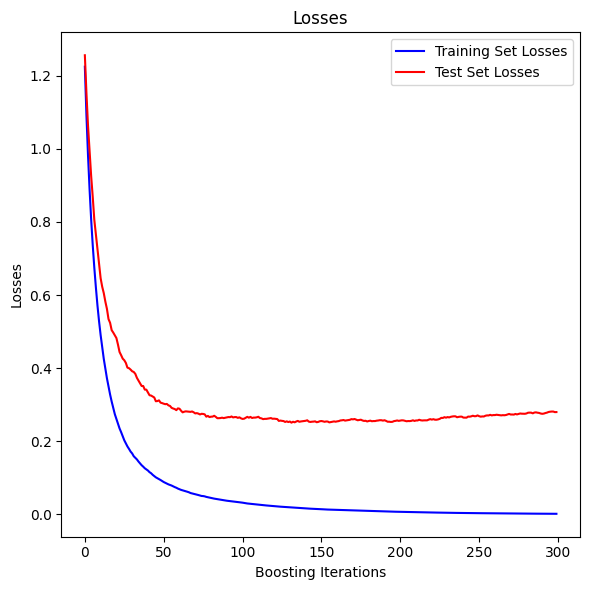

In [85]:
n_estimators=300
losses = np.zeros((n_estimators,), dtype=np.float64)
for i, y_proba in enumerate(classmodel.staged_predict_proba(X_test)):
        losses[i] = 2 * log_loss(y_test, y_proba[:,1])

fig = plt.figure(figsize=(6, 6))
plt.subplot(1, 1, 1)
plt.title("Losses")
plt.plot(
    np.arange(n_estimators),
    classmodel.train_score_,
    "b-",
    label="Training Set Losses",
)
plt.plot(
    np.arange(n_estimators), losses, "r-", label="Test Set Losses"
)
plt.legend(loc="upper right")
plt.xlabel("Boosting Iterations")
plt.ylabel("Losses")
fig.tight_layout()
plt.show()

/tmp/ipython-input-2626429678.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, **tick_labels_dict)


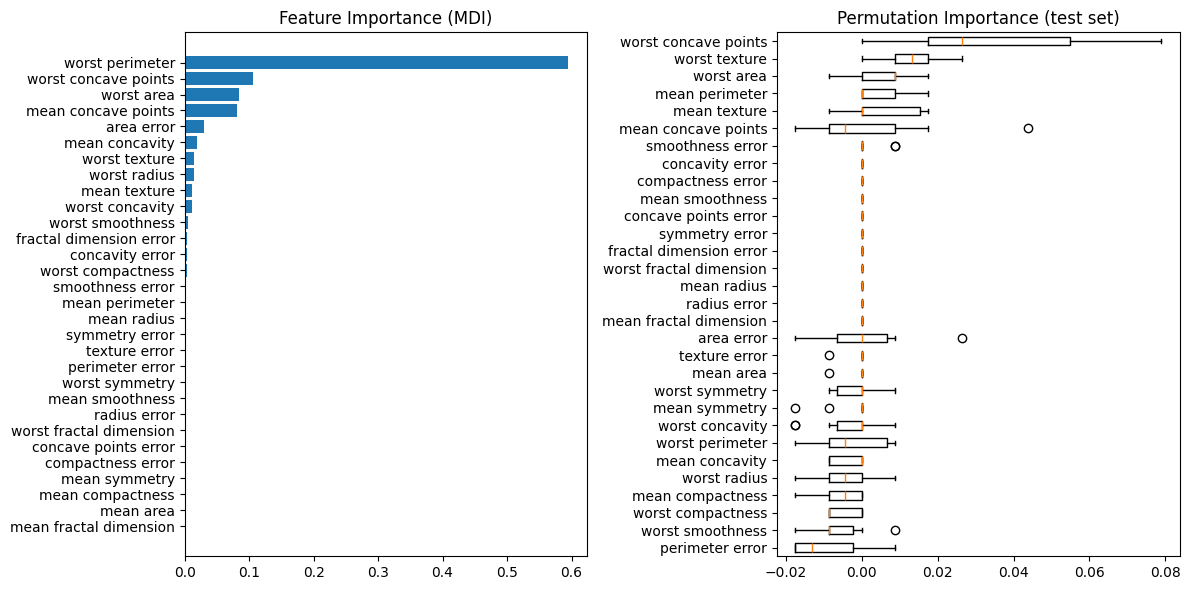

In [86]:
feature_importance = classmodel.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(bcancer.feature_names)[sorted_idx])
plt.title("Feature Importance (MDI)")

result = permutation_importance(
    classmodel, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)

tick_labels_dict = {
    "labels": np.array(bcancer.feature_names)[sorted_idx]
}
plt.boxplot(result.importances[sorted_idx].T, vert=False, **tick_labels_dict)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()

In [87]:
bcancer=datasets.load_breast_cancer()
X, y = bcancer.data, bcancer.target
data_dmatrix = xgb.DMatrix(data=X,label=y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

In [1]:
param_dist  = {
              'objective':['binary:logistic'],
              'n_estimators': [30, 100, 200],
              'max_depth' : [2,3,4, 5],
              'learning_rate' :[0.01, 0.1, 1],
              'alpha':[5, 10, 20],
             }

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn import datasets
import xgboost as xgb


params = {
            'objective':'binary:logistic',
            'max_depth': 3,
            'alpha': 5,
            'learning_rate': 0.1,
            'n_estimators':30
        }

bcancer=datasets.load_breast_cancer()
X, y = bcancer.data, bcancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
sample_weights = compute_sample_weight('balanced', y_train)

xgb_clf = xgb.XGBClassifier(**params, booster='gbtree')
xgb_clf.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(alpha=5, base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=30,
              n_jobs=None, ...)

In [9]:
confusion_matrix(y_test,xgb_clf.predict(X_test))

array([[35,  7],
       [ 4, 68]])

In [12]:
data_dmatrix = xgb.DMatrix(data=X,label=y)

result=xgb.cv(dtrain=data_dmatrix, params=params, nfold=3,
                    num_boost_round=100, early_stopping_rounds=10, metrics="auc",as_pandas=True)
print(result)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:225: UserWarning: [03:04:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  return getattr(self.bst, name)(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:231: UserWarning: [03:04:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  self.bst.update(self.dtrain, iteration, fobj)


    train-auc-mean  train-auc-std  test-auc-mean  test-auc-std
0         0.983992       0.004606       0.946808      0.011789
1         0.990675       0.006820       0.965263      0.015314
2         0.994157       0.002832       0.973368      0.008331
3         0.994142       0.003142       0.974974      0.004725
4         0.994738       0.002690       0.974977      0.005716
5         0.994753       0.002680       0.975407      0.005474
6         0.995057       0.002440       0.976817      0.006157
7         0.995176       0.002390       0.977127      0.006597
8         0.995363       0.002485       0.977347      0.006881
9         0.995547       0.002514       0.978565      0.007589
10        0.995716       0.002578       0.979127      0.007414
11        0.995800       0.002666       0.981685      0.009029
12        0.995924       0.002625       0.981443      0.008972
13        0.995874       0.002728       0.982138      0.009159
14        0.996742       0.002236       0.982343      0

<Figure size 600x400 with 0 Axes>

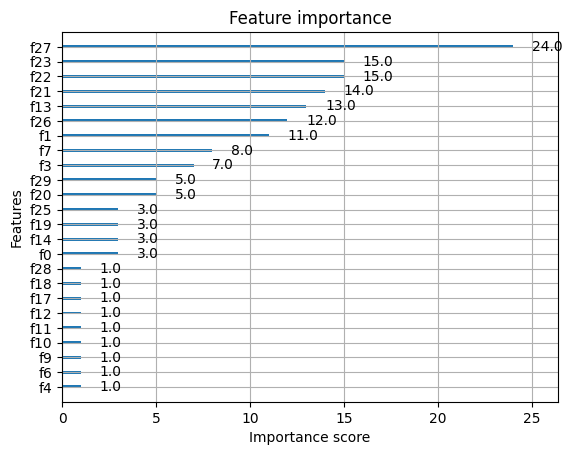

In [13]:
plt.figure(figsize=[6,4])
xgb.plot_importance(xgb_clf)
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


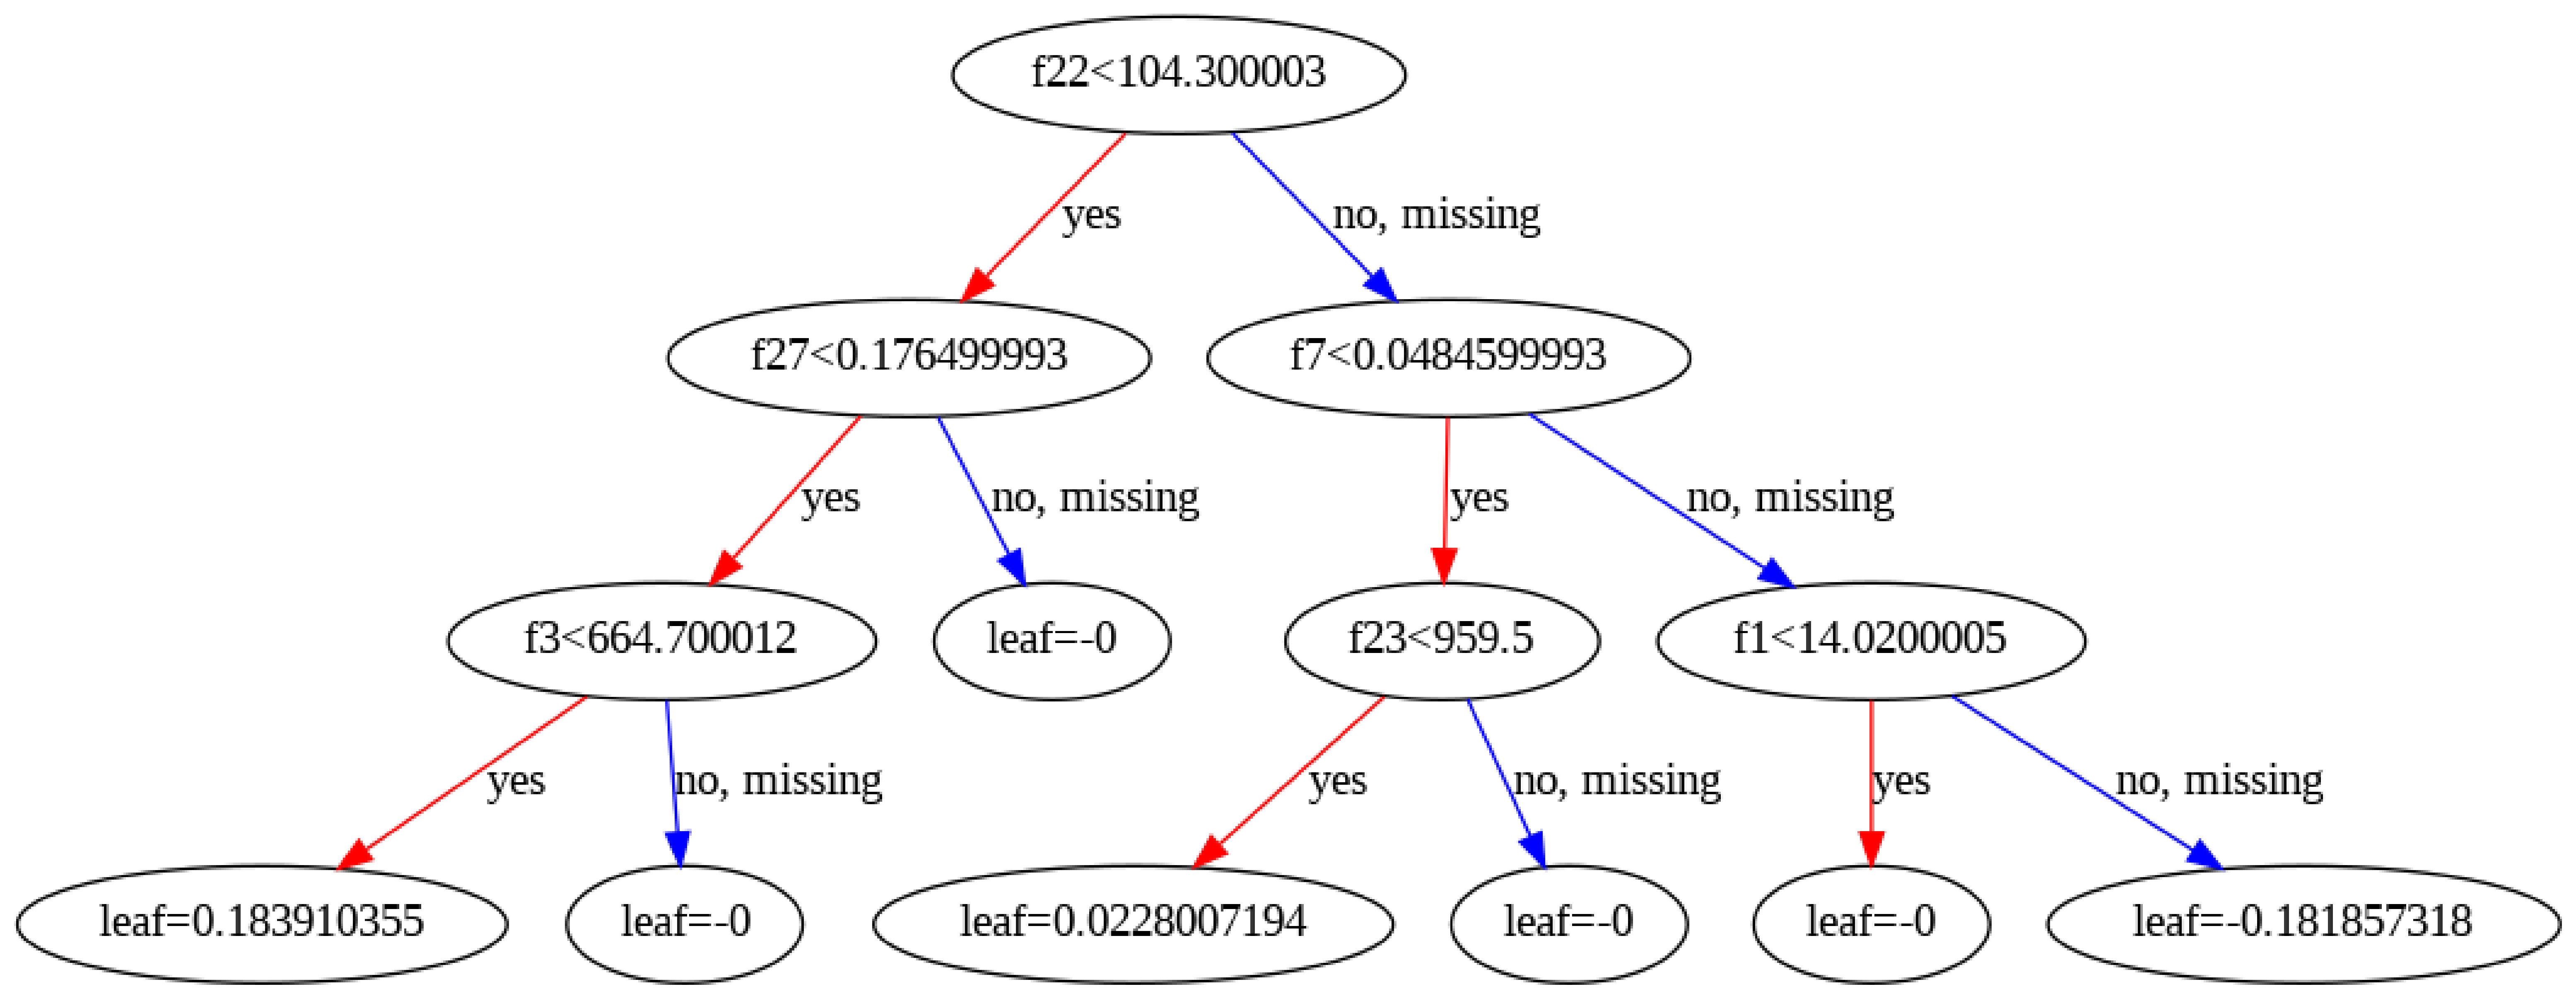

In [14]:
rcParams['figure.figsize'] = 80,50
xgb.plot_tree(xgb_clf, num_trees=0)
plt.show()